# Industrial Surface Defect Detection Using Deep Learning and Explainable AI
## Milestone 3 — Validation Analysis and Threshold Selection

**Selected model:** Frozen-backbone MobileNetV2  
**Selection data:** Validation split only  
**Reserved data:** The test split is not evaluated in this notebook.

This notebook evaluates the best validation-selected MobileNetV2 checkpoint, analyzes errors, selects a binary operating threshold, and derives preliminary confidence thresholds for a three-state human-review mechanism.

## 1. Methodological rules

- The model checkpoint was selected using validation loss during Standard training.
- Thresholds are selected using validation predictions only.
- Defective recall is prioritized because missed industrial defects are costly.
- The binary threshold objective is maximum F1 among thresholds achieving at least 90% defective recall.
- Human-review thresholds prioritize zero observed defective images in the automatic-good region and at least 90% precision in the automatic-defective region.
- These guarantees are empirical on a small validation set and must not be interpreted as population guarantees.
- Test data remains untouched until the model and thresholds are frozen.

In [3]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
DEFAULT_THRESHOLD = 0.50
MINIMUM_DEFECT_RECALL = 0.90
MINIMUM_AUTO_DEFECT_PRECISION = 0.90

PROJECT_ROOT = Path.cwd().resolve()
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "tile" / "manifests" / "tile_supervised_splits.csv"
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "milestone2" / "mobilenetv2_transfer_best.keras"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
ANALYSIS_DIR = OUTPUT_ROOT / "analysis" / "milestone3"
FIGURE_DIR = OUTPUT_ROOT / "figures" / "milestone3"

tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Model exists: {MODEL_PATH.is_file()}")
print(f"Manifest exists: {MANIFEST_PATH.is_file()}")

TensorFlow version: 2.21.0
Model exists: True
Manifest exists: True


## 2. Load the fixed validation split

The manifest integrity is checked again. Only rows explicitly assigned to validation are used for inference.

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 347
assert manifest["relative_path"].is_unique
assert set(manifest["split"]) == {"train", "validation", "test"}
assert manifest.groupby("group_id")["split"].nunique().max() == 1
assert manifest.groupby("sha256")["split"].nunique().max() == 1

validation_frame = (
    manifest.loc[manifest["split"] == "validation"]
    .sort_values("relative_path")
    .reset_index(drop=True)
)
assert len(validation_frame) == 54
assert validation_frame["source_path"].map(lambda value: Path(value).is_file()).all()

print(f"Validation images: {len(validation_frame)}")
display(pd.crosstab(validation_frame["binary_class"], validation_frame["defect_type"], margins=True))

Validation images: 54


defect_type,crack,glue_strip,good,gray_stroke,oil,rough,All
binary_class,,,,,,,
defective,3,3,0,3,3,2,14
good,0,0,40,0,0,0,40
All,3,3,40,3,3,2,54


## 3. Load the best MobileNetV2 checkpoint and predict

The saved model already contains MobileNetV2 preprocessing and the trained classification head. Inference uses no augmentation because Keras random augmentation layers are inactive outside training.

In [5]:
def decode_resize(path: tf.Tensor) -> tf.Tensor:
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_png(image_bytes, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    return tf.cast(image, tf.float32)


prediction_dataset = (
    tf.data.Dataset.from_tensor_slices(validation_frame["source_path"].astype(str).to_numpy())
    .map(decode_resize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
probabilities = model.predict(prediction_dataset, verbose=0).reshape(-1)
true_labels = validation_frame["binary_label"].astype(int).to_numpy()

assert len(probabilities) == len(validation_frame)
assert np.isfinite(probabilities).all()
assert ((probabilities >= 0) & (probabilities <= 1)).all()

predictions = validation_frame[
    ["source_path", "relative_path", "binary_class", "binary_label", "defect_type", "split"]
].copy()
predictions["predicted_probability"] = probabilities

print(pd.Series(probabilities).describe().round(4))
display(predictions.head())

count    54.0000
mean      0.3098
std       0.3276
min       0.0389
25%       0.0875
50%       0.1345
75%       0.4530
max       1.0000
dtype: float64


,source_path,relative_path,binary_class,binary_label,defect_type,split,predicted_probability
0,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/000.png,defective,1,crack,validation,0.999990
1,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/002.png,defective,1,crack,validation,0.999942
2,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/016.png,defective,1,crack,validation,0.999803
3,D:\Final Project\data\raw\mvtec_ad\tile\test\g...,test/glue_strip/005.png,defective,1,glue_strip,validation,0.966404
4,D:\Final Project\data\raw\mvtec_ad\tile\test\g...,test/glue_strip/009.png,defective,1,glue_strip,validation,0.848074


## 4. Evaluation utilities

All threshold-dependent metrics use the convention `probability >= threshold → defective`.

In [6]:
def metrics_at_threshold(y_true: np.ndarray, y_probability: np.ndarray, threshold: float) -> dict:
    y_pred = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) else 0.0,
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "predicted_defective": int(y_pred.sum()),
    }


def plot_confusion(y_true, y_probability, threshold, title, output_path):
    y_pred = (y_probability >= threshold).astype(int)
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, axis = plt.subplots(figsize=(5.5, 4.5))
    image = axis.imshow(matrix, cmap="Blues")
    for row in range(2):
        for column in range(2):
            axis.text(column, row, matrix[row, column], ha="center", va="center", fontsize=13)
    axis.set_xticks([0, 1], ["Good", "Defective"])
    axis.set_yticks([0, 1], ["Good", "Defective"])
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    axis.set_title(title)
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()

## 5. Default threshold analysis

The default 0.50 threshold provides a transparent reference point before any validation-based threshold adjustment.

,threshold,tn,fp,fn,tp,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,predicted_defective
0,0.5,38,2,4,10,0.8889,0.8333,0.7143,0.7692,0.2857,0.05,12


,precision,recall,f1-score,support
good,0.9048,0.9500,0.9268,40.0000
defective,0.8333,0.7143,0.7692,14.0000
accuracy,0.8889,0.8889,0.8889,0.8889
macro avg,0.8690,0.8321,0.8480,54.0000
weighted avg,0.8862,0.8889,0.8860,54.0000


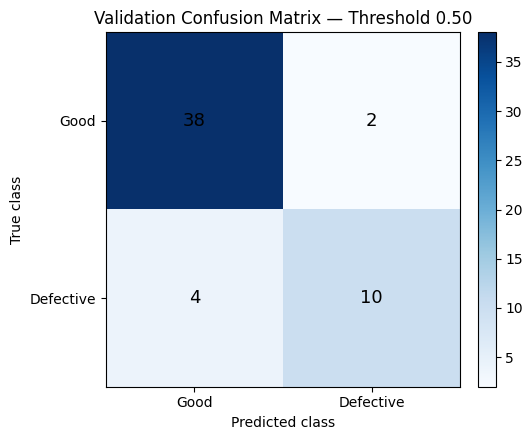

In [7]:
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

default_metrics = metrics_at_threshold(true_labels, probabilities, DEFAULT_THRESHOLD)
display(pd.DataFrame([default_metrics]).round(4))

default_labels = (probabilities >= DEFAULT_THRESHOLD).astype(int)
default_report = pd.DataFrame(
    classification_report(
        true_labels,
        default_labels,
        labels=[0, 1],
        target_names=["good", "defective"],
        output_dict=True,
        zero_division=0,
    )
).T
display(default_report.round(4))

plot_confusion(
    true_labels,
    probabilities,
    DEFAULT_THRESHOLD,
    "Validation Confusion Matrix — Threshold 0.50",
    FIGURE_DIR / "confusion_matrix_threshold_0_50.png",
)

## 6. Threshold sweep and operating-point selection

Candidate thresholds include a dense 0.01 grid and every observed validation probability. The selected threshold maximizes F1 while satisfying defective recall ≥ 0.90. Ties prefer higher precision and then a higher threshold.

In [8]:
candidate_thresholds = np.unique(
    np.concatenate([
        np.linspace(0.01, 0.99, 99),
        probabilities,
    ])
)
threshold_table = pd.DataFrame(
    [metrics_at_threshold(true_labels, probabilities, threshold) for threshold in candidate_thresholds]
).sort_values("threshold").reset_index(drop=True)

eligible = threshold_table.loc[threshold_table["recall"] >= MINIMUM_DEFECT_RECALL].copy()
if eligible.empty:
    raise RuntimeError("No threshold satisfies the minimum defective-recall constraint.")

selected_row = eligible.sort_values(
    ["f1", "precision", "threshold"],
    ascending=[False, False, False],
).iloc[0]
SELECTED_THRESHOLD = float(selected_row["threshold"])

print(f"Selected binary threshold: {SELECTED_THRESHOLD:.6f}")
print(f"Recall constraint: >= {MINIMUM_DEFECT_RECALL:.2f}")
display(pd.DataFrame([default_metrics, selected_row.to_dict()]).round(4))

threshold_table.to_csv(ANALYSIS_DIR / "validation_threshold_sweep.csv", index=False)

Selected binary threshold: 0.450239
Recall constraint: >= 0.90


,threshold,tn,fp,fn,tp,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,predicted_defective
0,0.5000,38.0,2.0,4.0,10.0,0.8889,0.8333,0.7143,0.7692,0.2857,0.05,12.0
1,0.4502,38.0,2.0,1.0,13.0,0.9444,0.8667,0.9286,0.8966,0.0714,0.05,15.0


,precision,recall,f1-score,support
good,0.9744,0.9500,0.9620,40.0000
defective,0.8667,0.9286,0.8966,14.0000
accuracy,0.9444,0.9444,0.9444,0.9444
macro avg,0.9205,0.9393,0.9293,54.0000
weighted avg,0.9464,0.9444,0.9451,54.0000


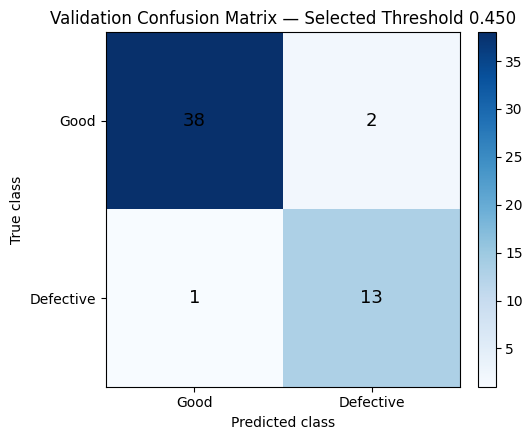

In [9]:
selected_metrics = metrics_at_threshold(true_labels, probabilities, SELECTED_THRESHOLD)
selected_labels = (probabilities >= SELECTED_THRESHOLD).astype(int)

selected_report = pd.DataFrame(
    classification_report(
        true_labels,
        selected_labels,
        labels=[0, 1],
        target_names=["good", "defective"],
        output_dict=True,
        zero_division=0,
    )
).T
display(selected_report.round(4))

plot_confusion(
    true_labels,
    probabilities,
    SELECTED_THRESHOLD,
    f"Validation Confusion Matrix — Selected Threshold {SELECTED_THRESHOLD:.3f}",
    FIGURE_DIR / "confusion_matrix_selected_threshold.png",
)

## 7. ROC, precision-recall, and threshold trade-offs

ROC-AUC and PR-AUC are threshold-independent summaries. PR-AUC is especially informative for the minority defective class.

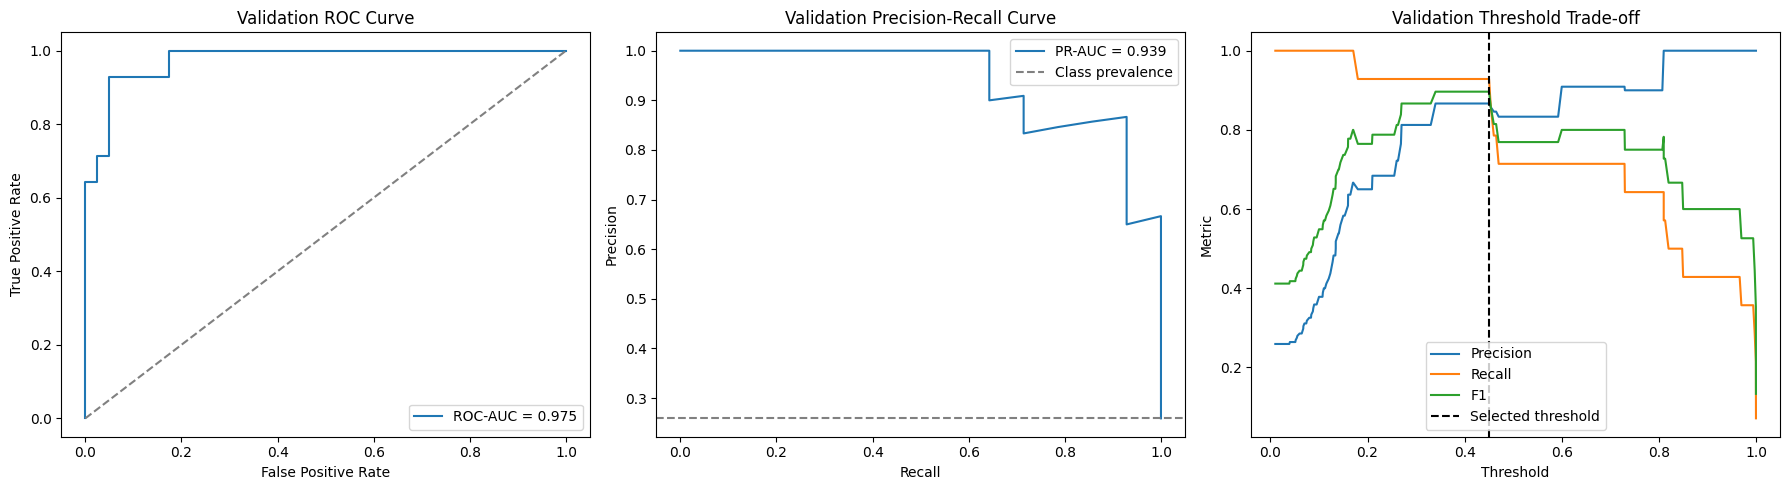

Validation ROC-AUC: 0.9750
Validation PR-AUC: 0.9390


In [10]:
roc_auc = roc_auc_score(true_labels, probabilities)
pr_auc = average_precision_score(true_labels, probabilities)
fpr, tpr, _ = roc_curve(true_labels, probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(true_labels, probabilities)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Validation ROC Curve")
axes[0].legend()

axes[1].plot(curve_recall, curve_precision, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].axhline(true_labels.mean(), linestyle="--", color="gray", label="Class prevalence")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Validation Precision-Recall Curve")
axes[1].legend()

axes[2].plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
axes[2].plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
axes[2].plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
axes[2].axvline(SELECTED_THRESHOLD, linestyle="--", color="black", label="Selected threshold")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Metric")
axes[2].set_title("Validation Threshold Trade-off")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "roc_pr_threshold_curves.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

## 8. Error analysis at the selected threshold

False positives and false negatives are listed and visualized. This helps determine whether errors are associated with specific defect types or ambiguous textures.

In [11]:
predictions["predicted_class_selected"] = np.where(selected_labels == 1, "defective", "good")
predictions["correct_selected"] = selected_labels == true_labels
predictions["error_type"] = np.select(
    [
        (true_labels == 0) & (selected_labels == 1),
        (true_labels == 1) & (selected_labels == 0),
    ],
    ["false_positive", "false_negative"],
    default="correct",
)

errors = predictions.loc[predictions["error_type"] != "correct"].copy()
print("Errors at selected threshold:")
display(errors[
    ["relative_path", "defect_type", "binary_class", "predicted_probability", "predicted_class_selected", "error_type"]
].sort_values(["error_type", "predicted_probability"]))

per_defect = (
    predictions.loc[predictions["binary_label"] == 1]
    .groupby("defect_type")
    .agg(
        image_count=("binary_label", "size"),
        detected_count=("predicted_class_selected", lambda values: int((values == "defective").sum())),
        mean_probability=("predicted_probability", "mean"),
    )
)
per_defect["recall"] = per_defect["detected_count"] / per_defect["image_count"]
display(per_defect.round(4))

Errors at selected threshold:


,relative_path,defect_type,binary_class,predicted_probability,predicted_class_selected,error_type
12,test/gray_stroke/005.png,gray_stroke,defective,0.170508,good,false_negative
32,train/good/078.png,good,good,0.592494,defective,false_positive
45,train/good/168.png,good,good,0.807148,defective,false_positive


,image_count,detected_count,mean_probability,recall
defect_type,,,,
crack,3,3,0.9999,1.0000
glue_strip,3,3,0.9373,1.0000
gray_stroke,3,2,0.4500,0.6667
oil,3,3,0.7573,1.0000
rough,2,2,0.6320,1.0000


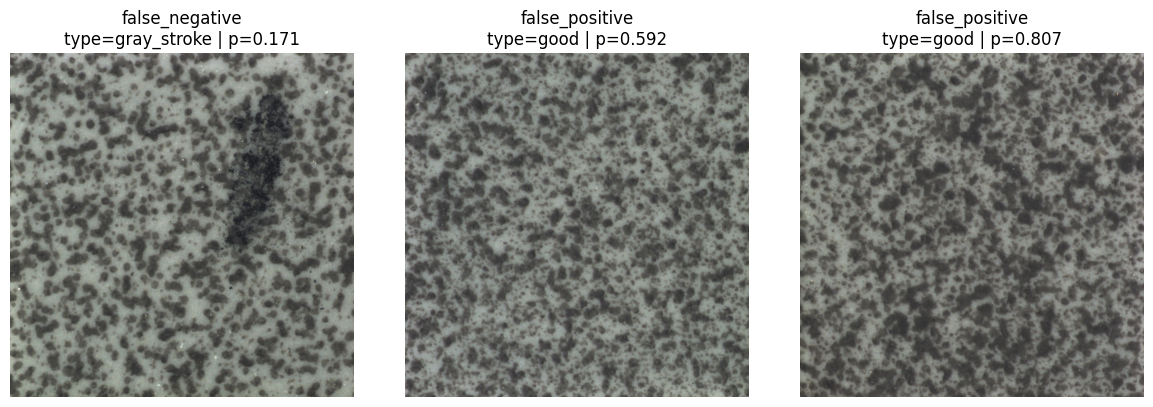

In [12]:
def show_error_examples(frame: pd.DataFrame, max_images: int = 12):
    if frame.empty:
        print("No errors to display.")
        return

    shown = frame.sort_values("predicted_probability").head(max_images)
    columns = min(4, len(shown))
    rows = int(np.ceil(len(shown) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows), squeeze=False)
    for axis in axes.ravel():
        axis.axis("off")

    for axis, record in zip(axes.ravel(), shown.itertuples(index=False)):
        with Image.open(record.source_path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f"{record.error_type}\n"
            f"type={record.defect_type} | p={record.predicted_probability:.3f}"
        )
        axis.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "selected_threshold_error_examples.png", dpi=160, bbox_inches="tight")
    plt.show()


show_error_examples(errors)

## 9. Preliminary three-state human-review mechanism

The validation-derived rules are:

- **Good:** probability below the largest observed boundary that sends no validation defect to automatic good.
- **Defective:** probability at or above the lowest boundary achieving at least 90% precision.
- **Needs Human Review:** probabilities between these two boundaries.

The boundaries must be frozen before test evaluation. Their apparent safety is limited by the small validation sample.

In [13]:
positive_probabilities = probabilities[true_labels == 1]
LOW_THRESHOLD = float(positive_probabilities.min())

high_precision_candidates = threshold_table.loc[
    (threshold_table["precision"] >= MINIMUM_AUTO_DEFECT_PRECISION)
    & (threshold_table["predicted_defective"] > 0)
    & (threshold_table["threshold"] > LOW_THRESHOLD)
].copy()

if high_precision_candidates.empty:
    HIGH_THRESHOLD = SELECTED_THRESHOLD
    print("No separate high-confidence threshold met the precision target; using the selected binary threshold.")
else:
    HIGH_THRESHOLD = float(high_precision_candidates["threshold"].min())

if HIGH_THRESHOLD <= LOW_THRESHOLD:
    HIGH_THRESHOLD = float(np.nextafter(LOW_THRESHOLD, 1.0))

predictions["predicted_class_binary"] = np.where(
    predictions["predicted_probability"] >= SELECTED_THRESHOLD,
    "defective",
    "good",
)
predictions["final_decision"] = np.select(
    [
        predictions["predicted_probability"] < LOW_THRESHOLD,
        predictions["predicted_probability"] >= HIGH_THRESHOLD,
    ],
    ["Good", "Defective"],
    default="Needs Human Review",
)

predictions["correct_or_incorrect"] = np.select(
    [
        predictions["final_decision"] == "Needs Human Review",
        predictions["final_decision"].str.lower() == predictions["binary_class"],
    ],
    ["not_applicable_review", "correct"],
    default="incorrect",
)

print(f"Low threshold: {LOW_THRESHOLD:.6f}")
print(f"High threshold: {HIGH_THRESHOLD:.6f}")
display(predictions["final_decision"].value_counts().rename("count").to_frame())

automatic = predictions["final_decision"] != "Needs Human Review"
review_rate = float((~automatic).mean())
automatic_accuracy = float(
    (predictions.loc[automatic, "final_decision"].str.lower() == predictions.loc[automatic, "binary_class"]).mean()
) if automatic.any() else np.nan
missed_defects_as_good = int(
    ((predictions["binary_label"] == 1) & (predictions["final_decision"] == "Good")).sum()
)
auto_defective = predictions["final_decision"] == "Defective"
auto_defective_precision = float(
    predictions.loc[auto_defective, "binary_label"].mean()
) if auto_defective.any() else np.nan

human_review_summary = {
    "low_threshold": LOW_THRESHOLD,
    "high_threshold": HIGH_THRESHOLD,
    "review_rate": review_rate,
    "automatic_coverage": float(automatic.mean()),
    "automatic_accuracy": automatic_accuracy,
    "missed_defects_as_automatic_good": missed_defects_as_good,
    "automatic_defective_precision": auto_defective_precision,
}
display(pd.DataFrame([human_review_summary]).round(4))

Low threshold: 0.170508
High threshold: 0.600000


,count
final_decision,
Good,33
Defective,11
Needs Human Review,10


,low_threshold,high_threshold,review_rate,automatic_coverage,automatic_accuracy,missed_defects_as_automatic_good,automatic_defective_precision
0,0.1705,0.6,0.1852,0.8148,0.9773,0,0.9091


## 10. Save validation artifacts

The prediction table includes the fields required for the later human-review deliverable. Test predictions are intentionally absent.

In [14]:
predictions_output = predictions.rename(columns={
    "relative_path": "image_id",
    "predicted_probability": "predicted_probability_defective",
    "binary_class": "true_label",
})
prediction_columns = [
    "image_id",
    "source_path",
    "predicted_probability_defective",
    "predicted_class_binary",
    "final_decision",
    "true_label",
    "correct_or_incorrect",
    "defect_type",
    "error_type",
]
prediction_path = ANALYSIS_DIR / "validation_predictions_and_human_review.csv"
predictions_output[prediction_columns].to_csv(prediction_path, index=False)

per_defect_path = ANALYSIS_DIR / "validation_per_defect_recall.csv"
per_defect.to_csv(per_defect_path)

selection_summary = {
    "model": "mobilenetv2_transfer_best.keras",
    "selection_split": "validation",
    "validation_images": int(len(validation_frame)),
    "validation_defective_images": int(true_labels.sum()),
    "default_threshold_metrics": default_metrics,
    "selected_binary_threshold": SELECTED_THRESHOLD,
    "selected_threshold_metrics": selected_metrics,
    "validation_roc_auc": float(roc_auc),
    "validation_pr_auc": float(pr_auc),
    "human_review": human_review_summary,
    "test_evaluated": False,
}
summary_path = ANALYSIS_DIR / "validation_threshold_selection_summary.json"
summary_path.write_text(json.dumps(selection_summary, indent=2), encoding="utf-8")

print("Saved artifacts:")
for path in (prediction_path, per_defect_path, summary_path):
    print(f"  - {path}")
print("Confirmed: test data was not evaluated.")

Saved artifacts:
  - D:\Final Project\outputs\analysis\milestone3\validation_predictions_and_human_review.csv
  - D:\Final Project\outputs\analysis\milestone3\validation_per_defect_recall.csv
  - D:\Final Project\outputs\analysis\milestone3\validation_threshold_selection_summary.json
Confirmed: test data was not evaluated.


## Conclusions

This notebook determines whether threshold adjustment is sufficient before considering fine-tuning. The selected binary threshold and the preliminary human-review boundaries are validation-derived development decisions. Because only 14 defective validation images are available, per-defect and threshold estimates have substantial uncertainty.

### Next decision

Review the executed false negatives, false positives, per-defect recall, selected binary threshold, and human-review referral rate. Based on these results, decide whether controlled fine-tuning is justified before freezing the final model and evaluating the test set.